# DQMC for the half-filled 2D Hubbard model

This notebook implements determinant quantum Monte Carlo on a periodic square lattice. It uses one consistent slice convention throughout:

$$
B_l^\sigma=V_l^\sigma K_{\Delta\tau},\qquad
V_l^\sigma=\operatorname{diag}\!\left(e^{\sigma\alpha S_{il}}\right),\qquad
K_{\Delta\tau}=e^{-\Delta\tau K}.
$$

Here `K_matrix` is the single-particle hopping matrix and `exp_minus_dtau_K` is its imaginary-time propagator. The name `T` is not used for the kinetic matrix.

Two kinetic propagators are available:

1. `make_exact_K_propagators`: directly evaluates the full matrix exponential. This is the simplest and preferred reference implementation.
2. `make_checkerboard_K_propagators`: factorizes the hopping into two families of disjoint plaquettes. It is useful when applying local blocks is cheaper than exponentiating a large matrix.

Both choices feed the same SVD stabilization and DQMC sweep code. Diagnostic-history storage has been removed, while the complete sweep-by-sweep `sq_measurements` time series is retained.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as sla
import pickle
import os

#np.set_printoptions(precision=6, suppress=True)

## 1. Square-lattice kinetic matrix

`make_K_matrix` constructs

$$
H_K=\sum_{ij\sigma}c^\dagger_{i\sigma}(K_{\mathrm{matrix}})_{ij}c_{j\sigma},
$$

with matrix element \(-t\) between nearest neighbours and periodic boundary conditions. Each undirected bond is inserted once and then symmetrized.


In [7]:
def make_K_matrix(L, hopping):
    """Return the nearest-neighbour square-lattice hopping matrix with PBC."""
    if L < 3:
        raise ValueError("Use L >= 3; L=2 has duplicated periodic neighbours.")

    number_sites = L * L
    K_matrix = np.zeros((number_sites, number_sites), dtype=float)

    def site_index(x, y):
        return (x % L) + L * (y % L)

    for y in range(L):
        for x in range(L):
            i = site_index(x, y)
            # Right and upper bonds generate every undirected bond once.
            for j in (site_index(x + 1, y), site_index(x, y + 1)):
                K_matrix[i, j] = -hopping
                K_matrix[j, i] = -hopping

    return K_matrix


## 2. Exact and checkerboard kinetic propagators

The exact option returns

$$
e^{-\Delta\tau K},\qquad e^{+\Delta\tau K}=(e^{-\Delta\tau K})^{-1}.
$$

For the checkerboard option, write $K=K_A+K_B$, where each family contains disjoint $2\times2$ plaquettes. The first-order factorization is

$$
e^{-\Delta\tau K}\approx e^{-\Delta\tau K_A}e^{-\Delta\tau K_B}.
$$

Its inverse must use the reverse order:

$$
\left(e^{-\Delta\tau K_A}e^{-\Delta\tau K_B}\right)^{-1}
=e^{+\Delta\tau K_B}e^{+\Delta\tau K_A}.
$$

The checkerboard factorization introduces an additional finite-$\Delta\tau$ error. Use the exact option when validating the DQMC and SVD logic.


In [3]:
def make_exact_K_propagators(K_matrix, delta_tau):
    """Return the exact exp(-dt K) propagator and its inverse."""
    exp_minus_dtau_K = sla.expm(-delta_tau * K_matrix)
    exp_plus_dtau_K = sla.expm(+delta_tau * K_matrix)
    return exp_minus_dtau_K, exp_plus_dtau_K


def make_checkerboard_family_propagator(L, hopping, delta_tau, offset):
    """Return exp(-dt K_family) for one family of disjoint plaquettes."""
    if L < 4 or L % 2 != 0:
        raise ValueError("The plaquette checkerboard requires an even L >= 4.")
    if offset not in (0, 1):
        raise ValueError("offset must be 0 or 1.")

    # Exact exponential of the four-site hopping ring in one plaquette.
    c2 = np.cosh(2.0 * delta_tau * hopping)
    s2 = np.sinh(2.0 * delta_tau * hopping)
    same_site = 0.5 * (c2 + 1.0)
    edge = 0.5 * s2
    opposite_corner = 0.5 * (c2 - 1.0)
    plaquette_exp = np.array([
        [same_site, edge, opposite_corner, edge],
        [edge, same_site, edge, opposite_corner],
        [opposite_corner, edge, same_site, edge],
        [edge, opposite_corner, edge, same_site],
    ])

    number_sites = L * L
    family_exp = np.zeros((number_sites, number_sites), dtype=float)

    for y in range(offset, L, 2):
        for x in range(offset, L, 2):
            plaquette_sites = [
                x + y * L,
                ((x + 1) % L) + y * L,
                ((x + 1) % L) + ((y + 1) % L) * L,
                x + ((y + 1) % L) * L,
            ]
            family_exp[np.ix_(plaquette_sites, plaquette_sites)] = plaquette_exp

    return family_exp


def make_checkerboard_K_propagators(L, hopping, delta_tau):
    """Return checkerboard exp(-dt K) and its exact reverse-order inverse."""
    family_A_minus = make_checkerboard_family_propagator(
        L, hopping, +delta_tau, offset=0
    )
    family_B_minus = make_checkerboard_family_propagator(
        L, hopping, +delta_tau, offset=1
    )
    family_A_plus = make_checkerboard_family_propagator(
        L, hopping, -delta_tau, offset=0
    )
    family_B_plus = make_checkerboard_family_propagator(
        L, hopping, -delta_tau, offset=1
    )

    exp_minus_dtau_K = family_A_minus @ family_B_minus
    exp_plus_dtau_K = family_B_plus @ family_A_plus
    return exp_minus_dtau_K, exp_plus_dtau_K


## 3. Hubbard-Stratonovich field and slice matrices

For the repulsive half-filled Hubbard model,

$$
\cosh\alpha=e^{U\Delta\tau/2}.
$$

`build_B_matrix` always uses the requested $V_lK_{\Delta\tau}$ order. Consequently,

$
B_l^{-1}=K_{\Delta\tau}^{-1}V_l^{-1}.
$

`cyclic_B_matrices(tau, ...)` returns the matrices in chronological order starting at the boundary $\tau$. Left multiplication of this list produces the cyclic product inside $G(\tau)$.


In [4]:
def build_B_matrix(slice_index, spin, auxiliary_field, alpha, exp_minus_dtau_K):
    """Construct B_l^sigma = V_l^sigma exp(-dt K)."""
    potential = np.exp(spin * alpha * auxiliary_field[:, slice_index])
    return potential[:, None] * exp_minus_dtau_K


def build_B_inverse(slice_index, spin, auxiliary_field, alpha, exp_plus_dtau_K):
    """Construct (B_l^sigma)^(-1) = exp(+dt K) (V_l^sigma)^(-1)."""
    inverse_potential = np.exp(-spin * alpha * auxiliary_field[:, slice_index])
    return exp_plus_dtau_K * inverse_potential[None, :]


def cyclic_B_matrices(tau, spin, auxiliary_field, alpha, exp_minus_dtau_K):
    """Return the cyclic chronological B list defining the equal-time G(tau)."""
    number_slices = auxiliary_field.shape[1]
    cyclic_order = list(range(tau, number_slices)) + list(range(0, tau))
    return [
        build_B_matrix(l, spin, auxiliary_field, alpha, exp_minus_dtau_K)
        for l in cyclic_order
    ]


def form_B_blocks(B_matrices, block_size):
    """Group chronological slice matrices into short left-multiplied blocks."""
    matrix_size = B_matrices[0].shape[0]
    blocks = []
    for start in range(0, len(B_matrices), block_size):
        block = np.eye(matrix_size)
        for B_matrix in B_matrices[start:start + block_size]:
            block = B_matrix @ block
        blocks.append(block)
    return blocks


## 4. Sequential two-step SVD stabilization

`svd_factor_B_product` represents the cyclic product as

$$
P(\tau)=UDV^T,
$$

while isolating its exponentially large and small scales in the diagonal singular-value vector. `svd_green_from_factors` then evaluates

$$
G(\tau)=[I+P(\tau)]^{-1}
$$

without first forming the ill-conditioned full product.

`recompute_G_svd` is the only function the Monte Carlo driver needs for reconstruction from scratch.


In [5]:
def svd_factor_B_product(B_matrices, block_size):
    """Compute U, singular values, Vh for the full left product of B matrices."""
    B_blocks = form_B_blocks(B_matrices, block_size)
    U, singular_values, Vh = sla.svd(B_blocks[0], full_matrices=False, lapack_driver="gesvd",)

    for B_block in B_blocks[1:]:
        # First SVD treats the new well-conditioned block and the old U.
        U_outer, outer_values, Vh_outer = sla.svd(
            B_block @ U, full_matrices=False, lapack_driver="gesvd",
        )

        # Second SVD combines the new scales with all accumulated old scales.
        inner_matrix = (
            outer_values[:, None] * Vh_outer
        ) * singular_values[None, :]
        U_inner, singular_values, Vh_inner = sla.svd(
            inner_matrix, full_matrices=False, lapack_driver="gesvd",
        )

        U = U_outer @ U_inner
        Vh = Vh_inner @ Vh

    return U, singular_values, Vh


def svd_green_from_factors(U, singular_values, Vh):
    """Stably calculate G=(I+U diag(d) Vh)^(-1) by splitting large scales."""
    large_values = np.maximum(singular_values, 1.0)
    small_values = np.minimum(singular_values, 1.0)

    right_hand_side = (1.0 / large_values)[:, None] * U.T
    core_matrix = right_hand_side + small_values[:, None] * Vh
    return np.linalg.solve(core_matrix, right_hand_side)


def recompute_G_svd(tau, spin, auxiliary_field, alpha,
                    exp_minus_dtau_K, block_size):
    """Reconstruct the equal-time Green function G^sigma(tau) from scratch."""
    B_matrices = cyclic_B_matrices(
        tau, spin, auxiliary_field, alpha, exp_minus_dtau_K
    )
    U, singular_values, Vh = svd_factor_B_product(B_matrices, block_size)
    return svd_green_from_factors(U, singular_values, Vh)


## 5. Local field updates and observables

Because $B_l=V_lK_{\Delta\tau}$, the forward sweep first wraps

$
G(l+1)=B_lG(l)B_l^{-1},
$

using the old field at slice $l$. At that boundary, flipping $S_{il}$ changes the cyclic product by a left diagonal factor, so the standard Sherman-Morrison formula applies.

In the reverse sweep, the code already stores $G(l+1)$. It therefore updates the field first and wraps backward afterward using the updated $B_l$.

The measured structure factor is

$$
S(\pi,\pi)=\frac{1}{N}\sum_{ij}(-1)^{x_i+y_i+x_j+y_j}
\langle S_i^zS_j^z\rangle,
\qquad S_i^z=\frac12(n_{i\uparrow}-n_{i\downarrow}).
$$


In [6]:
def update_auxiliary_slice(G_up, G_dn, auxiliary_field, slice_index, alpha, rng):
    """Attempt every local HS-field flip at one slice using Sherman-Morrison."""
    number_sites = auxiliary_field.shape[0]
    accepted = 0

    for site in range(number_sites):
        old_field = auxiliary_field[site, slice_index]
        field_change = -2 * old_field

        delta_up = np.expm1(+alpha * field_change)
        delta_dn = np.expm1(-alpha * field_change)
        ratio_up = 1.0 + delta_up * (1.0 - G_up[site, site])
        ratio_dn = 1.0 + delta_dn * (1.0 - G_dn[site, site])
        determinant_ratio = ratio_up * ratio_dn

        if not np.isfinite(determinant_ratio):
            raise FloatingPointError("Non-finite determinant ratio encountered.")
        
        # Metropolis acceptance step
        if rng.random() < min(1.0, abs(determinant_ratio)):
            auxiliary_field[site, slice_index] = -old_field
            row_up = -G_up[site, :].copy()
            row_up[site] += 1.0
            column_up = G_up[:, site].copy()
            G_up -= (delta_up / ratio_up) * np.outer(column_up, row_up)

            row_dn = -G_dn[site, :].copy()
            row_dn[site] += 1.0
            column_dn = G_dn[:, site].copy()
            G_dn -= (delta_dn / ratio_dn) * np.outer(column_dn, row_dn)
            accepted += 1

    return G_up, G_dn, accepted


def measure_equal_time_observables(G_up, G_dn):
    """Return density, double occupancy, and S(pi,pi) for the current field."""
    number_sites = G_up.shape[0]
    L = int(round(np.sqrt(number_sites)))
    if L * L != number_sites:
        raise ValueError("S(pi,pi) requires a square L-by-L lattice.")

    density_up = 1.0 - np.diag(G_up)
    density_dn = 1.0 - np.diag(G_dn)
    density = np.mean(density_up + density_dn)
    double_occupancy = np.mean(density_up * density_dn)

    magnetization_z = density_up - density_dn
    connected_up = np.diag(np.diag(G_up)) - G_up.T * G_up
    connected_dn = np.diag(np.diag(G_dn)) - G_dn.T * G_dn
    spin_correlation = 0.25 * (
        np.outer(magnetization_z, magnetization_z)
        + connected_up
        + connected_dn
    )

    x = np.arange(number_sites) % L
    y = np.arange(number_sites) // L
    staggered_phase = (-1.0) ** (x + y)
    phase_matrix = np.outer(staggered_phase, staggered_phase)
    S_pi_pi = np.real(np.sum(phase_matrix * spin_correlation)) / number_sites

    return density, double_occupancy, S_pi_pi


## 6. DQMC sweep driver

One sweep consists of a forward pass followed by a reverse pass. Measurements are taken after every updated forward time slice and averaged over all $L_\tau$ slices. Reconstruction from scratch occurs every `safe_interval` slices.

The returned dictionary contains summary statistics and the full arrays

- `density_measurements`
- `double_occupancy_measurements`
- `sq_measurements`

so the Monte Carlo time series remains available for autocorrelation or binning analysis.


In [7]:
def run_dqmc_sweeps(number_sites, number_slices, interaction, delta_tau,
                    exp_minus_dtau_K, exp_plus_dtau_K,
                    warmup_sweeps=500, measurement_sweeps=2000,
                    safe_interval=5, seed=1234):
    """Run stabilized forward-and-reverse DQMC sweeps at half filling."""
    rng = np.random.default_rng(seed)
    alpha = np.arccosh(np.exp(0.5 * interaction * delta_tau))
    auxiliary_field = rng.choice((-1, 1), size=(number_sites, number_slices))

    G_up = recompute_G_svd(
        0, +1, auxiliary_field, alpha, exp_minus_dtau_K, safe_interval
    )
    # At U=0, every auxiliary-field configuration is equivalent.
    if interaction == 0.0:
        density, double_occupancy, S_pi_pi = (
            measure_equal_time_observables(G_up, G_up.copy())
        )

        return {
            "density": (float(density), 0.0),
            "double_occupancy": (float(double_occupancy), 0.0),
            "S_pi_pi": (float(S_pi_pi), 0.0),
            "density_measurements": np.full(measurement_sweeps, density),
            "double_occupancy_measurements": np.full(
                measurement_sweeps, double_occupancy
            ),
            "sq_measurements": np.full(measurement_sweeps, S_pi_pi),
            "acceptance_rate": np.nan,  # No updates were attempted.
            "final_auxiliary_field": auxiliary_field,
        }
    
    G_dn = recompute_G_svd(
        0, -1, auxiliary_field, alpha, exp_minus_dtau_K, safe_interval
    )

    density_measurements = []
    double_occupancy_measurements = []
    sq_measurements = []
    accepted_updates = 0
    attempted_updates = 0

    total_sweeps = warmup_sweeps + measurement_sweeps
    for sweep in range(total_sweeps):
        measure_this_sweep = sweep >= warmup_sweeps
        density_sum = 0.0
        double_occupancy_sum = 0.0
        sq_sum = 0.0

        # Forward pass: wrap with the old B_l, then update S[:, l].
        for l in range(number_slices):
            B_up = build_B_matrix(l, +1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_up = build_B_inverse(l, +1, auxiliary_field, alpha, exp_plus_dtau_K)
            B_dn = build_B_matrix(l, -1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_dn = build_B_inverse(l, -1, auxiliary_field, alpha, exp_plus_dtau_K)

            G_up = B_up @ G_up @ B_inv_up
            G_dn = B_dn @ G_dn @ B_inv_dn

            G_up, G_dn, accepted = update_auxiliary_slice(
                G_up, G_dn, auxiliary_field, l, alpha, rng
            )
            accepted_updates += accepted
            attempted_updates += number_sites

            # The current boundary is tau=l+1.
            if (l + 1) % safe_interval == 0:
                tau = l + 1
                G_up = recompute_G_svd(
                    tau, +1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )
                G_dn = recompute_G_svd(
                    tau, -1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )

            if measure_this_sweep:
                density, double_occupancy, S_pi_pi = measure_equal_time_observables(
                    G_up, G_dn
                )
                density_sum += density
                double_occupancy_sum += double_occupancy
                sq_sum += S_pi_pi

        # Reverse pass: update at G(l+1), then wrap backward with updated B_l.
        for l in range(number_slices - 1, -1, -1):
            G_up, G_dn, accepted = update_auxiliary_slice(
                G_up, G_dn, auxiliary_field, l, alpha, rng
            )
            accepted_updates += accepted
            attempted_updates += number_sites

            B_up = build_B_matrix(l, +1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_up = build_B_inverse(l, +1, auxiliary_field, alpha, exp_plus_dtau_K)
            B_dn = build_B_matrix(l, -1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_dn = build_B_inverse(l, -1, auxiliary_field, alpha, exp_plus_dtau_K)

            G_up = B_inv_up @ G_up @ B_up
            G_dn = B_inv_dn @ G_dn @ B_dn

            # The current boundary is tau=l.
            if l % safe_interval == 0:
                G_up = recompute_G_svd(
                    l, +1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )
                G_dn = recompute_G_svd(
                    l, -1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )

        if measure_this_sweep:
            density_measurements.append(density_sum / number_slices)
            double_occupancy_measurements.append(double_occupancy_sum / number_slices)
            sq_measurements.append(sq_sum / number_slices)

    density_measurements = np.asarray(density_measurements)
    double_occupancy_measurements = np.asarray(double_occupancy_measurements)
    sq_measurements = np.asarray(sq_measurements)

    def mean_and_naive_sem(samples):
        if len(samples) < 2:
            return float(np.mean(samples)), np.nan
        return float(np.mean(samples)), float(np.std(samples, ddof=1) / np.sqrt(len(samples)))

    return {
        "density": mean_and_naive_sem(density_measurements),
        "double_occupancy": mean_and_naive_sem(double_occupancy_measurements),
        "S_pi_pi": mean_and_naive_sem(sq_measurements),
        "density_measurements": density_measurements,
        "double_occupancy_measurements": double_occupancy_measurements,
        "sq_measurements": sq_measurements,
        "acceptance_rate": accepted_updates / attempted_updates,
        "final_auxiliary_field": auxiliary_field,
    }


## 7. Choose parameters and run

The defaults match the QR benchmark: $L=4$, $t=1$, $\beta=3$, $\Delta\tau=0.1$, and `safe_interval=5`.

Set `kinetic_method` to either `"exact"` or `"checkerboard"`. Use the exact option first. For production error bars, the naive standard errors returned below should later be replaced by binning or an integrated-autocorrelation-time analysis.


In [116]:
import time

L = 6
number_sites = L * L
hopping = 1.0
beta = 6.0
delta_tau = 0.1
number_slices = int(round(beta / delta_tau))

safe_intervals_to_run = [10]
U_values_to_run = [6.0]

filename = f"dqmc_results_L{L}_beta{beta}.pkl"

warmup_sweeps = 1000
measurement_sweeps = 4000
kinetic_method = "checkerboard"

# Construct the kinetic matrices only once.
K_matrix = make_K_matrix(L, hopping)

if kinetic_method == "exact":
    exp_minus_dtau_K, exp_plus_dtau_K = make_exact_K_propagators(
        K_matrix, delta_tau
    )
elif kinetic_method == "checkerboard":
    exp_minus_dtau_K, exp_plus_dtau_K = make_checkerboard_K_propagators(
        L, hopping, delta_tau
    )
else:
    raise ValueError(
        "kinetic_method must be 'exact' or 'checkerboard'."
    )

inverse_residual = np.linalg.norm(
    exp_minus_dtau_K @ exp_plus_dtau_K - np.eye(number_sites)
)

print(f"Kinetic method: {kinetic_method}")
print(f"Inverse residual: {inverse_residual:.3e}")

Kinetic method: checkerboard
Inverse residual: 2.830e-15


In [117]:

# These dictionaries contain only results calculated in this run.
computed_results = {}
computed_run_times = {}

for safe_interval in safe_intervals_to_run:
    computed_results[safe_interval] = {}
    computed_run_times[safe_interval] = {}

    print(f"\nSafe interval = {safe_interval}")

    for U in U_values_to_run:
        print(f"Starting U={U:g}, safe_interval={safe_interval}")

        start_time = time.perf_counter()

        result = run_dqmc_sweeps(
            number_sites=number_sites,
            number_slices=number_slices,
            interaction=U,
            delta_tau=delta_tau,
            exp_minus_dtau_K=exp_minus_dtau_K,
            exp_plus_dtau_K=exp_plus_dtau_K,
            warmup_sweeps=warmup_sweeps,
            measurement_sweeps=measurement_sweeps,
            safe_interval=safe_interval,
            seed= 125 + int(100 * U),
        )

        elapsed_time = time.perf_counter() - start_time

        computed_results[safe_interval][U] = result
        computed_run_times[safe_interval][U] = elapsed_time

        print(
            f"U={U:3.1f}: "
            f"density={result['density'][0]:.12f}, "
            f"double_occ={result['double_occupancy'][0]:.6f}, "
            f"S(pi,pi)={result['S_pi_pi'][0]:.6f}, "
            f"acceptance={result['acceptance_rate']:.4f}, "
            f"time={elapsed_time:.2f} s"
        )

print("\nComputation finished. Nothing has been saved yet.")


Safe interval = 10
Starting U=6, safe_interval=10
U=6.0: density=1.000000000000, double_occ=0.076163, S(pi,pi)=2.033120, acceptance=0.4767, time=1395.02 s

Computation finished. Nothing has been saved yet.


In [118]:
import os
import pickle


archive_filename = f"dqmc_archive_L{L}_beta{beta}.pkl"

system_parameters = {
    "L": L,
    "hopping": hopping,
    "beta": beta,
    "delta_tau": delta_tau,
    "number_slices": number_slices,
    "kinetic_method": kinetic_method,
}


# Load the existing archive or create a new one.
if os.path.exists(archive_filename):
    with open(archive_filename, "rb") as file:
        archive = pickle.load(file)

    for name, expected_value in system_parameters.items():
        stored_value = archive[
            "system_parameters"
        ].get(name)

        if stored_value != expected_value:
            raise ValueError(
                f"Archive has {name}={stored_value}, "
                f"but current {name}={expected_value}."
            )

else:
    archive = {
        "schema_version": 2,
        "system_parameters": system_parameters,
        "runs": [],
    }


# Identify existing runs without using seed information.
existing_runs = {
    (
        float(run["U"]),
        int(run["safe_interval"]),
        int(run["warmup_sweeps"]),
        int(run["measurement_sweeps"]),
    )
    for run in archive["runs"]
}


number_added = 0


for safe_interval, interval_results in computed_results.items():
    for U, result in interval_results.items():
        identity = (
            float(U),
            int(safe_interval),
            int(warmup_sweeps),
            int(measurement_sweeps),
        )

        if identity in existing_runs:
            print(
                "Already stored; skipping "
                f"U={U:g}, "
                f"safe={safe_interval}, "
                f"warmup={warmup_sweeps}, "
                f"measurements={measurement_sweeps}"
            )
            continue

        archive["runs"].append({
            "U": float(U),
            "safe_interval": int(safe_interval),
            "warmup_sweeps": int(warmup_sweeps),
            "measurement_sweeps": int(
                measurement_sweeps
            ),
            "run_time_seconds": float(
                computed_run_times[safe_interval][U]
            ),
            "result": result,
        })

        existing_runs.add(identity)
        number_added += 1


# Sort the archive.
archive["runs"].sort(
    key=lambda run: (
        run["U"],
        run["safe_interval"],
        run["warmup_sweeps"],
        run["measurement_sweeps"],
    )
)


# Save atomically.
if number_added > 0:
    temporary_filename = archive_filename + ".tmp"

    with open(temporary_filename, "wb") as file:
        pickle.dump(archive, file)

    os.replace(temporary_filename, archive_filename)

    print(
        f"Added {number_added} runs. "
        f"Archive now contains "
        f"{len(archive['runs'])} runs."
    )

else:
    print("Nothing new to save.")

Added 1 runs. Archive now contains 13 runs.


## 8. Structure factor and retained time series

The first plot shows the mean raw structure factor, which already contains the $1/N$ normalization. The second plot displays the retained Monte Carlo time series for the selected interaction.


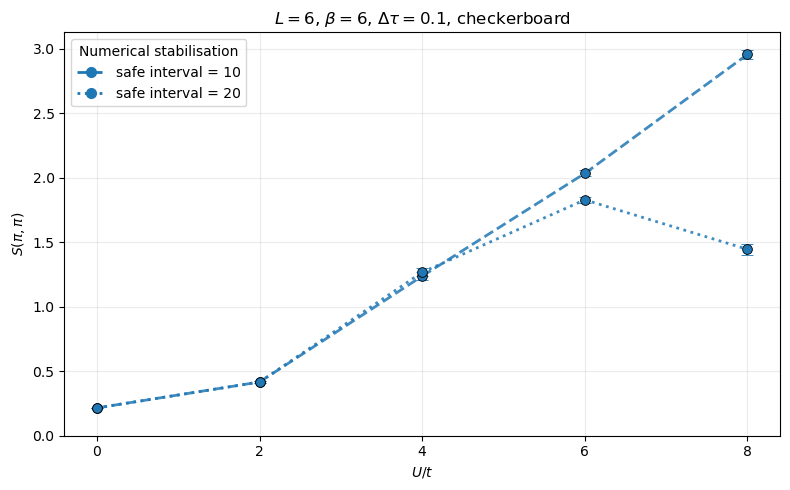

In [122]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import defaultdict


archive_filename = "dqmc_archive_L6_beta6.0.pkl"

with open(archive_filename, "rb") as file:
    archive = pickle.load(file)

runs = archive["runs"]
parameters = archive["system_parameters"]

L = parameters["L"]
beta = parameters["beta"]
delta_tau = parameters["delta_tau"]
kinetic_method = parameters["kinetic_method"]


# One colour for the complete (L, beta) family.
family_colour = "tab:blue"

# Line style represents safe interval.
line_styles = {
    5: "-",
    10: "--",
    20: ":",
}

# Organise runs as grouped_runs[safe_interval][U].
grouped_runs = defaultdict(lambda: defaultdict(list))

for run in runs:
    grouped_runs[run["safe_interval"]][run["U"]].append(
        run
    )


fig, ax = plt.subplots(figsize=(8, 5))


for safe_interval in sorted(grouped_runs):
    runs_by_U = grouped_runs[safe_interval]
    U_values = sorted(runs_by_U)

    linestyle = line_styles.get(
        safe_interval,
        "--",
    )

    # Plot every archived result as a point with an error bar.
    for U in U_values:
        for run in runs_by_U[U]:
            sq_mean, sq_error = run["result"]["S_pi_pi"]

            ax.errorbar(
                U,
                sq_mean,
                yerr=sq_error,
                color=family_colour,
                marker="o",
                linestyle="none",
                markersize=7,
                capsize=4,
                markeredgecolor="black",
                markeredgewidth=0.6,
                zorder=3,
            )

    # Connect consecutive U values.
    #
    # If one U contains multiple results, every result is
    # connected to the point or points at the preceding U.
    # Thus both U=8 results are connected to U=6.
    for previous_U, current_U in zip(
        U_values[:-1],
        U_values[1:],
    ):
        previous_runs = runs_by_U[previous_U]
        current_runs = runs_by_U[current_U]

        for previous_run in previous_runs:
            previous_mean = previous_run[
                "result"
            ]["S_pi_pi"][0]

            for current_run in current_runs:
                current_mean = current_run[
                    "result"
                ]["S_pi_pi"][0]

                ax.plot(
                    [previous_U, current_U],
                    [previous_mean, current_mean],
                    color=family_colour,
                    linestyle=linestyle,
                    linewidth=2,
                    alpha=0.85,
                    zorder=2,
                )


# Legend showing only the safe-interval line styles.
legend_handles = [
    Line2D(
        [0],
        [0],
        color=family_colour,
        linestyle=line_styles.get(
            safe_interval,
            "--",
        ),
        marker="o",
        linewidth=2,
        markersize=7,
        label=f"safe interval = {safe_interval}",
    )
    for safe_interval in sorted(grouped_runs)
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    title="Numerical stabilisation",
)


ax.set_xticks(sorted({
    run["U"]
    for run in runs
}))

ax.set_xlabel(r"$U/t$")
ax.set_ylabel(r"$S(\pi,\pi)$")
ax.set_title(
    rf"$L={L}$, $\beta={beta:g}$, "
    rf"$\Delta\tau={delta_tau:g}$, "
    f"{kinetic_method}"
)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

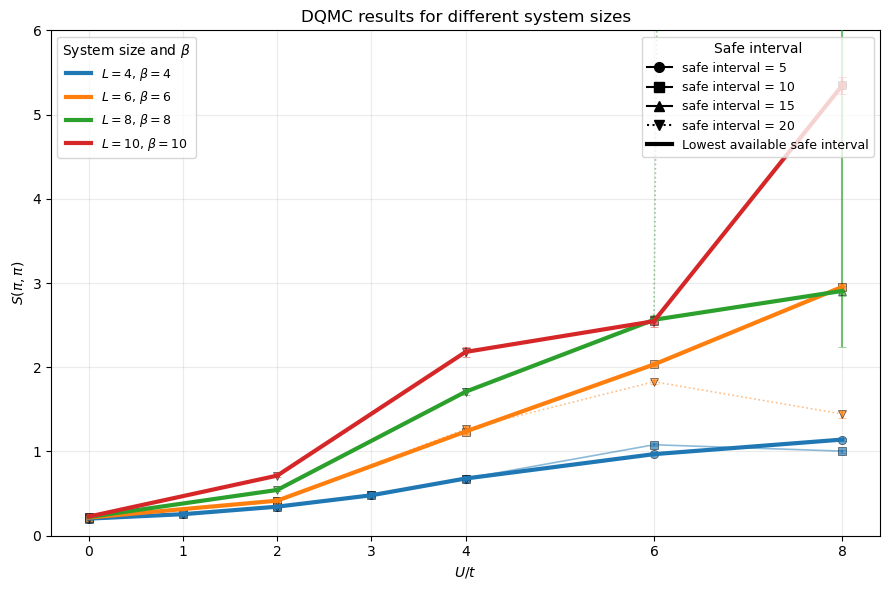

In [123]:
import pickle
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from collections import defaultdict


# Datasets to load: (L, beta)
datasets = [
    (4, 4.0),
    (6, 6.0),
    (8, 8.0),
    (10, 10.0),
]

loaded_archives = {}


# ------------------------------------------------------------
# Load and validate the standardised archive files
# ------------------------------------------------------------

for expected_L, expected_beta in datasets:
    filename = (
        f"dqmc_archive_L{expected_L}"
        f"_beta{expected_beta}.pkl"
    )

    with open(filename, "rb") as file:
        archive = pickle.load(file)

    parameters = archive["system_parameters"]

    stored_L = parameters["L"]
    stored_beta = parameters["beta"]

    if stored_L != expected_L or stored_beta != expected_beta:
        raise ValueError(
            f"{filename} contains L={stored_L}, "
            f"beta={stored_beta}, but L={expected_L}, "
            f"beta={expected_beta} was expected."
        )

    loaded_archives[(stored_L, stored_beta)] = archive


# Collect all safe intervals appearing in any archive.
all_safe_intervals = sorted({
    run["safe_interval"]
    for archive in loaded_archives.values()
    for run in archive["runs"]
})


# ------------------------------------------------------------
# Visual style
# ------------------------------------------------------------

# Colour identifies the (L, beta) family.
colour_map = plt.get_cmap("tab10")

family_colours = {
    family: colour_map(index)
    for index, family in enumerate(loaded_archives)
}


# Marker shape identifies the safe interval.
available_markers = ["o", "s", "^", "v", "P", "X"]

interval_markers = {
    safe_interval: available_markers[
        index % len(available_markers)
    ]
    for index, safe_interval in enumerate(
        all_safe_intervals
    )
}


# Safe interval 20 is dotted; all others are solid.
interval_line_styles = {
    safe_interval: (
        ":" if safe_interval == 20 else "-"
    )
    for safe_interval in all_safe_intervals
}


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 6))


for family, archive in loaded_archives.items():
    L, beta = family
    colour = family_colours[family]

    # Organise runs as:
    # runs_by_interval[safe_interval][U] = [run, ...]
    runs_by_interval = defaultdict(
        lambda: defaultdict(list)
    )

    for run in archive["runs"]:
        runs_by_interval[
            run["safe_interval"]
        ][run["U"]].append(run)

    # --------------------------------------------------------
    # Plot every safe-interval curve
    # --------------------------------------------------------

    for safe_interval in sorted(runs_by_interval):
        runs_by_U = runs_by_interval[safe_interval]
        U_values = sorted(runs_by_U)

        marker = interval_markers[safe_interval]
        linestyle = interval_line_styles[safe_interval]

        # Plot every archived result and its error bar.
        for U in U_values:
            for run in runs_by_U[U]:
                sq_mean, sq_error = (
                    run["result"]["S_pi_pi"]
                )

                ax.errorbar(
                    U,
                    sq_mean,
                    yerr=sq_error,
                    color=colour,
                    marker=marker,
                    linestyle="none",
                    markersize=6,
                    capsize=3,
                    alpha=0.65,
                    markeredgecolor="black",
                    markeredgewidth=0.5,
                    zorder=3,
                )

        # Connect consecutive U values.
        #
        # If one U contains multiple runs, every point at
        # that U is connected to every point at the previous U.
        for previous_U, current_U in zip(
            U_values[:-1],
            U_values[1:],
        ):
            previous_runs = runs_by_U[previous_U]
            current_runs = runs_by_U[current_U]

            for previous_run in previous_runs:
                previous_mean = previous_run[
                    "result"
                ]["S_pi_pi"][0]

                for current_run in current_runs:
                    current_mean = current_run[
                        "result"
                    ]["S_pi_pi"][0]

                    ax.plot(
                        [previous_U, current_U],
                        [previous_mean, current_mean],
                        color=colour,
                        linestyle=linestyle,
                        linewidth=1.2,
                        alpha=0.5,
                        zorder=2,
                    )

    # --------------------------------------------------------
    # Highlight the lowest available safe interval at each U
    # --------------------------------------------------------

    family_U_values = sorted({
        run["U"]
        for run in archive["runs"]
    })

    selected_runs_by_U = {}

    for U in family_U_values:
        available_intervals = sorted({
            run["safe_interval"]
            for run in archive["runs"]
            if run["U"] == U
        })

        if not available_intervals:
            continue

        lowest_safe_interval = min(
            available_intervals
        )

        # Retain every run at the selected safe interval.
        # Therefore, duplicate U=8 values are both retained.
        selected_runs_by_U[U] = [
            run
            for run in archive["runs"]
            if run["U"] == U
            and run["safe_interval"]
            == lowest_safe_interval
        ]

    selected_U_values = sorted(selected_runs_by_U)

    # Draw the thicker main curve.
    #
    # If U=8 contains two selected values, both are connected
    # to the selected U=6 point.
    for previous_U, current_U in zip(
        selected_U_values[:-1],
        selected_U_values[1:],
    ):
        previous_runs = selected_runs_by_U[previous_U]
        current_runs = selected_runs_by_U[current_U]

        for previous_run in previous_runs:
            previous_mean = previous_run[
                "result"
            ]["S_pi_pi"][0]

            for current_run in current_runs:
                current_mean = current_run[
                    "result"
                ]["S_pi_pi"][0]

                ax.plot(
                    [previous_U, current_U],
                    [previous_mean, current_mean],
                    color=colour,
                    linestyle="-",
                    linewidth=3,
                    zorder=4,
                )


# ------------------------------------------------------------
# Legends
# ------------------------------------------------------------

# First legend: colour identifies the family.
family_handles = [
    Line2D(
        [0],
        [0],
        color=family_colours[(L, beta)],
        linestyle="-",
        linewidth=3,
        label=rf"$L={L}$, $\beta={beta:g}$",
    )
    for L, beta in loaded_archives
]

family_legend = ax.legend(
    handles=family_handles,
    title=r"System size and $\beta$",
    loc="upper left",
    fontsize=9,
)

ax.add_artist(family_legend)


# Second legend: marker and line style identify safe interval.
interval_handles = [
    Line2D(
        [0],
        [0],
        color="black",
        marker=interval_markers[safe_interval],
        linestyle=interval_line_styles[safe_interval],
        linewidth=1.5,
        markersize=7,
        label=f"safe interval = {safe_interval}",
    )
    for safe_interval in all_safe_intervals
]

interval_handles.append(
    Line2D(
        [0],
        [0],
        color="black",
        linestyle="-",
        linewidth=3,
        label="Lowest available safe interval",
    )
)

ax.legend(
    handles=interval_handles,
    title="Safe interval",
    loc="upper right",
    fontsize=9,
)


# ------------------------------------------------------------
# Labels and layout
# ------------------------------------------------------------

ax.set_xticks(sorted({
    run["U"]
    for archive in loaded_archives.values()
    for run in archive["runs"]
}))

ax.set_xlabel(r"$U/t$")
ax.set_ylabel(r"$S(\pi,\pi)$")
ax.set_title("DQMC results for different system sizes")
ax.set_ylim(0, 6)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

## 9. Real Space MF

At zero temperature and half filling, construct the particle-hole-symmetric one-body Hamiltonians on the periodic square lattice:

$$
h_\uparrow=K+U\,\mathrm{diag}(\bar n_\downarrow-1/2),\qquad
h_\downarrow=K+U\,\mathrm{diag}(\bar n_\uparrow-1/2).
$$

Fill the lowest $N/2$ orbitals per spin and calculate only their site densities,

$$
\bar n_{i\sigma}^{\rm out}=\sum_{a=1}^{N/2}|\phi_{a\sigma}(i)|^2.
$$

Mix the input and output densities until the largest **unmixed** site-density change is below the tolerance. The solver returns one number: the staggered magnetisation

$$
m_s=\frac{1}{2N}\left|\sum_i(-1)^{x_i+y_i}
(\bar n_{i\uparrow}-\bar n_{i\downarrow})\right|.
$$

There is no need to construct full density matrices or Green functions. The density arrays remain site-dependent; the initial seed favours the Néel pattern. This is zero-temperature HF, whereas the DQMC simulations use finite $\beta$.


In [8]:
def zero_temperature_densities(hamiltonian, number_particles):
    """Return site densities by filling the lowest single-particle orbitals."""
    _, eigenvectors = np.linalg.eigh(hamiltonian)
    occupied_vectors = eigenvectors[:, :number_particles]
    return np.sum(np.abs(occupied_vectors)**2, axis=1)


def run_mean_field(
    L,
    interaction,
    hopping,
    mixing=0.5,
    tolerance=1.0e-10,
    max_iterations=5000,
):
    """Return only m_s from zero-temperature real-space Hartree-Fock."""
    if L % 2 != 0:
        raise ValueError("Use an even L for half-filled periodic Neel order.")
    if not np.isfinite(interaction) or interaction < 0:
        raise ValueError("interaction must be finite and non-negative.")
    if not np.isfinite(hopping) or hopping < 0:
        raise ValueError("hopping must be finite and non-negative.")
    if not 0 < mixing <= 1 or not np.isfinite(tolerance) or tolerance <= 0:
        raise ValueError("Use 0 < mixing <= 1 and a finite positive tolerance.")
    if not isinstance(max_iterations, (int, np.integer)) or max_iterations < 1:
        raise ValueError("max_iterations must be a positive integer.")

    number_sites = L * L
    K_matrix = make_K_matrix(L, hopping)
    x = np.arange(number_sites) % L
    y = np.arange(number_sites) // L
    staggered_phase = (-1.0) ** (x + y)

    # Small antiferromagnetic initial seed.
    density_up = 0.5 + 0.1 * staggered_phase
    density_dn = 0.5 - 0.1 * staggered_phase

    for _ in range(max_iterations):
        H_up = K_matrix + np.diag(interaction * (density_dn - 0.5))
        H_dn = K_matrix + np.diag(interaction * (density_up - 0.5))

        density_up_trial = zero_temperature_densities(H_up, number_sites // 2)
        density_dn_trial = zero_temperature_densities(H_dn, number_sites // 2)

        # Check the unmixed density change before updating.
        residual = max(
            np.max(np.abs(density_up_trial - density_up)),
            np.max(np.abs(density_dn_trial - density_dn)),
        )
        if residual < tolerance:
            return float(0.5 * abs(np.mean(
                staggered_phase * (density_up_trial - density_dn_trial)
            )))

        density_up = (1.0 - mixing) * density_up + mixing * density_up_trial
        density_dn = (1.0 - mixing) * density_dn + mixing * density_dn_trial

    raise RuntimeError(f"Mean-field iteration did not converge for U={interaction}.")


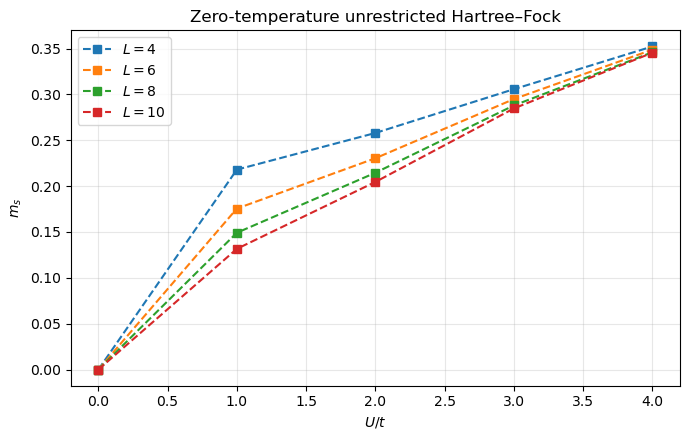

In [9]:
L_values = [4, 6, 8, 10]
U_values_mf = [0, 1, 2, 3, 4]

# Results are indexed as mean_field_results[L][U]
mean_field_results = {
    L: {
        U: run_mean_field(
            L=L,
            interaction=U,
            hopping=1.0,
        )
        for U in U_values_mf
    }
    for L in L_values
}


plt.figure(figsize=(7, 4.5))

for L in L_values:
    mean_field_magnetization = [
        mean_field_results[L][U]
        for U in U_values_mf
    ]

    plt.plot(
        U_values_mf,
        mean_field_magnetization,
        marker="s",
        linestyle="--",
        label=rf"$L={L}$",
    )

plt.xlabel(r"$U/t$")
plt.ylabel(r"$m_s$")
plt.title("Zero-temperature unrestricted Hartree–Fock")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Momentum-space MF - Neel Ansatz
 Here we use the same even, periodic $L\times L$ square lattice, $N=L^2$, and particle–hole-symmetric interaction $U(n_\uparrow-1/2)(n_\downarrow-1/2)$, with $U\geq0$.

Assume uniform charge and collinear Néel order:

$$
\bar n_{i\uparrow}=\frac12+\eta_i m,\qquad
\bar n_{i\downarrow}=\frac12-\eta_i m,\qquad
\eta_i=(-1)^{x_i+y_i}.
$$

Unlike unrestricted real-space HF, this fixes the spatial pattern and only solves for its amplitude. On the **full** Brillouin-zone grid $k_\mu=2\pi n_\mu/L$, calculate

$$
\epsilon_{\mathbf k}=-2t(\cos k_x+\cos k_y),\qquad
E_{\mathbf k}=\sqrt{\epsilon_{\mathbf k}^2+(Um)^2},\qquad
m_{\rm out}=\frac{1}{2N}\sum_{\mathbf k}\frac{Um}{E_{\mathbf k}}.
$$

The factor $1/2$ accounts for the two appearances of each $(\mathbf k,\mathbf k+\mathbf Q)$ pair. Fill the lower band and iterate $m\leftarrow(1-\alpha)m+\alpha m_{\rm out}$. Convergence is checked using the **unmixed** residual $|m_{\rm out}-m|$, so a small mixing parameter cannot falsely satisfy the tolerance.

For the energy per site in our shifted interaction convention,

$$
e(m)=Um^2-\frac1N\sum_{\mathbf k}E_{\mathbf k},\qquad
\frac{de}{dm}=2U(m-m_{\rm out}).
$$

For $U>0$, this mixed update is also gradient descent with learning rate $\alpha/(2U)$. No extra $U/4$ is added; that belongs to the unshifted interaction convention.

### Returned magnetisation

Like `run_mean_field`, this solver returns just the scalar staggered magnetisation $m_s=|m|$. Each iteration takes $O(N)$ work and memory.The comparison below reuses the real-space solver to check the magnetisation.

At exactly $U=0$, choose the nonmagnetic value $m_s=0$. Small positive $U$ selects the ordered branch and need not approach zero on a fixed finite grid with zero-energy modes.


In [10]:
def make_epsilon_k(L, hopping):
    """Return epsilon(k) on the full square-lattice PBC momentum grid."""
    if not isinstance(L, (int, np.integer)) or L < 4 or L % 2 != 0:
        raise ValueError("Use an even integer L >= 4 for periodic Neel order.")
    if not np.isfinite(hopping) or hopping < 0:
        raise ValueError("hopping must be finite and non-negative.")

    momenta = 2.0 * np.pi * np.arange(L) / L
    cosine = np.cos(momenta)
    epsilon_k = -2.0 * hopping * (cosine[:, None] + cosine[None, :]) #

    # cos(kx) + cos(ky) is exactly zero on these discrete Fermi-surface points.
    # Identify them by integer indices, not by an energy threshold that could
    # erase a genuinely small gap or misclassify weak hopping.
    indices = np.arange(L)
    zero_modes = (
        ((indices[:, None] + indices[None, :]) % L == L // 2)
        | ((indices[:, None] - indices[None, :]) % L == L // 2)
    )
    epsilon_k[zero_modes] = 0.0 #to avoid later the analytical formula being distorted by numerical noise. 
    
    return epsilon_k


def run_momentum_mean_field(
    L,
    interaction,
    hopping,
    mixing=0.5,
    tolerance=1.0e-10,
    max_iterations=5000,
):
    """Return only m_s from zero-temperature Neel HF on the full momentum grid."""
    if not np.isfinite(interaction) or interaction < 0:
        raise ValueError("interaction must be finite and non-negative.")
    if not 0 < mixing <= 1 or not np.isfinite(tolerance) or tolerance <= 0:
        raise ValueError("Use 0 < mixing <= 1 and a finite positive tolerance.")
    if not isinstance(max_iterations, (int, np.integer)) or max_iterations < 1:
        raise ValueError("max_iterations must be a positive integer.")

    epsilon_k = make_epsilon_k(L, hopping)
    if interaction == 0:
        return 0.0

    magnetisation = 0.1
    for _ in range(max_iterations):
        delta = interaction * magnetisation
        band_energy = np.hypot(epsilon_k, delta) #numpy function calculating the sqrt(x^2 + y^2) element-wise
        trial_magnetisation = 0.5 * np.mean(delta / band_energy)

        if abs(trial_magnetisation - magnetisation) < tolerance:
            return float(abs(trial_magnetisation))

        magnetisation = (
            (1.0 - mixing) * magnetisation
            + mixing * trial_magnetisation
        )

    raise RuntimeError(
        f"Momentum mean-field iteration did not converge for U={interaction}."
    )


In [11]:
# Compare only the staggered magnetisation returned by the two solvers.
for comparison_L in (4, 6):
    for comparison_U in (1.0, 4.0):
        real_space_m = run_mean_field(
            L=comparison_L, interaction=comparison_U, hopping=1.0,
        )
        momentum_space_m = run_momentum_mean_field(
            L=comparison_L, interaction=comparison_U, hopping=1.0,
        )
        np.testing.assert_allclose(real_space_m, momentum_space_m, atol=1.0e-8, rtol=1.0e-8)
        print(
            f"L={comparison_L}, U={comparison_U:g}: "
            f"real-space m_s={real_space_m:.8f}, "
            f"momentum-space m_s={momentum_space_m:.8f}"
        )


L=4, U=1: real-space m_s=0.21798927, momentum-space m_s=0.21798927
L=4, U=4: real-space m_s=0.35224584, momentum-space m_s=0.35224584
L=6, U=1: real-space m_s=0.17551825, momentum-space m_s=0.17551825
L=6, U=4: real-space m_s=0.34875886, momentum-space m_s=0.34875886


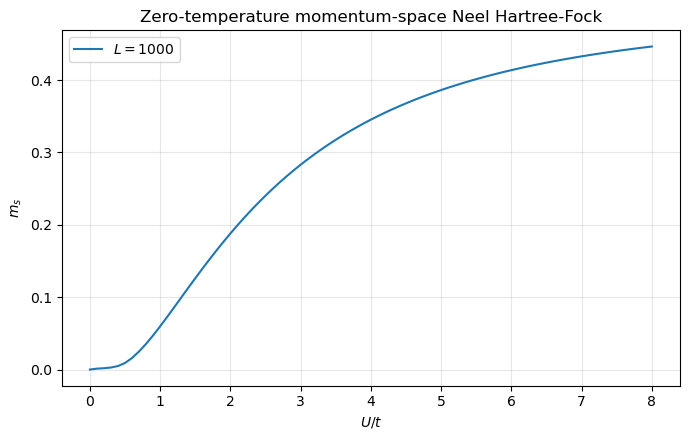

In [16]:
# Independent names preserve the earlier real-space and DQMC results.
momentum_L_values = [1000]
momentum_U_values = np.arange(0, 8.1, 0.1)

momentum_mean_field_results = {
    L: {
        U: run_momentum_mean_field(L=L, interaction=U, hopping=1.0)
        for U in momentum_U_values
    }
    for L in momentum_L_values
}

fig, ax = plt.subplots(figsize=(7, 4.5))
for L in momentum_L_values:
    magnetizations = [
        momentum_mean_field_results[L][U]
        for U in momentum_U_values
    ]
    ax.plot(momentum_U_values, magnetizations, label=rf"$L={L}$")

ax.set_xlabel(r"$U/t$")
ax.set_ylabel(r"$m_s$")
ax.set_title("Zero-temperature momentum-space Neel Hartree-Fock")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


# 11. Comparison 

L=4: selected (U, safe interval) = [(0.0, 5), (1.0, 5), (2.0, 5), (3.0, 5), (4.0, 5), (6.0, 5), (8.0, 5)]
Flagged: L=6, U=8, safe=20, double occupancy=-0.064627
L=6: selected (U, safe interval) = [(0.0, 10), (2.0, 10), (4.0, 10), (6.0, 10), (8.0, 10)]
Not plotted: L=8, U=8, safe=20, S=236.529
L=8: selected (U, safe interval) = [(0.0, 20), (2.0, 20), (4.0, 20), (6.0, 20), (8.0, 15)]
L=10: selected (U, safe interval) = [(0.0, 20), (2.0, 20), (4.0, 20), (6.0, 10), (8.0, 5)]


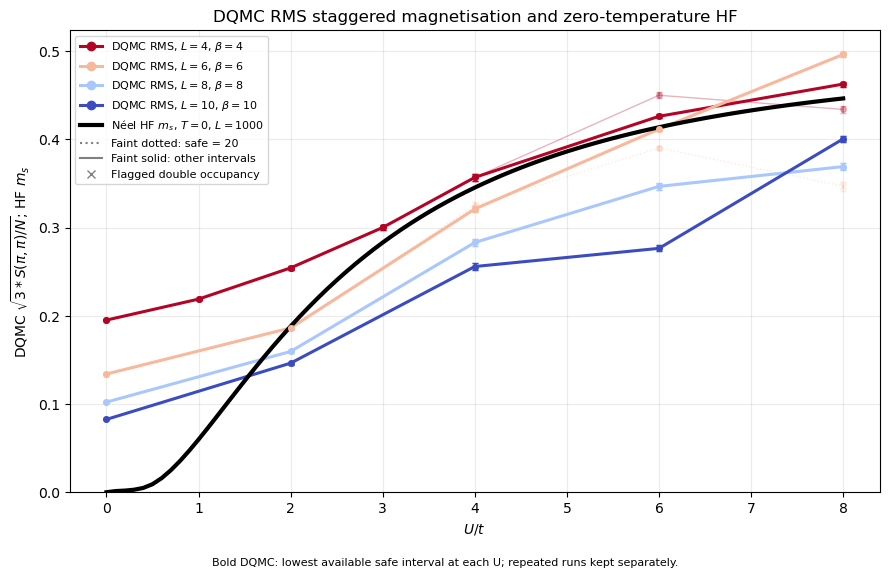

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D

# Settings
L_values = [4, 6, 8, 10]
L_mf = 1000
hopping = 1.0
show_other_intervals = True  # False gives a cleaner comparison.


# Small plotting helper, defined here so this cell is self-contained.
def plot_runs(ax, runs, colour, linestyle="-", linewidth=2, alpha=1):
    grouped = defaultdict(list)

    for run in runs:
        grouped[run["U"]].append(run)

        ax.errorbar(
            run["U"] / hopping,
            run["m"],
            yerr=[[run["error_minus"]], [run["error_plus"]]],
            fmt="x" if run["suspect"] else "o",
            color=colour,
            markersize=4,
            capsize=2,
            alpha=alpha,
        )

    # Keep repeated runs separate; connect each to the adjacent U values.
    U_values = sorted(grouped)

    for U_left, U_right in zip(U_values[:-1], U_values[1:]):
        for left in grouped[U_left]:
            for right in grouped[U_right]:
                ax.plot(
                    np.array([U_left, U_right]) / hopping,
                    [left["m"], right["m"]],
                    color=colour,
                    linestyle=linestyle,
                    linewidth=linewidth,
                    alpha=alpha,
                )


# Load the current archives, not the older dqmc_results files.
dqmc_data = {}

for L in L_values:
    beta = float(L)
    filename = f"dqmc_archive_L{L}_beta{beta}.pkl"

    with open(filename, "rb") as file:
        archive = pickle.load(file)

    parameters = archive["system_parameters"]

    for name, expected in (("L", L), ("beta", beta), ("hopping", hopping)):
        if parameters[name] != expected:
            raise ValueError(f"{filename}: unexpected {name}={parameters[name]}")

    points = []
    lowest_interval = {}

    for run in archive["runs"]:
        U = float(run["U"])
        safe = int(run["safe_interval"])
        lowest_interval[U] = min(safe, lowest_interval.get(U, safe))

        S, S_error = map(float, run["result"]["S_pi_pi"])

        # Physical bound for this Sz structure factor: 0 <= S <= N/4.
        if (
            not np.isfinite(S)
            or not np.isfinite(S_error)
            or not 0 <= S <= L * L / 4
            or S_error < 0
        ):
            print(f"Not plotted: L={L}, U={U:g}, safe={safe}, S={S:g}")
            continue

        # RMS staggered magnetisation, not the signed mean magnetisation.
        m = np.sqrt(3* S / (L * L))

        # Transform the stored error-bar endpoints.
        lower = np.sqrt(3* max(0.0, S - S_error) / (L * L))
        upper = np.sqrt(3 * (S + S_error) / (L * L))

        D = float(run["result"]["double_occupancy"][0])
        suspect = not np.isfinite(D) or not 0 <= D <= 0.5

        if suspect:
            print(
                f"Flagged: L={L}, U={U:g}, safe={safe}, "
                f"double occupancy={D:g}"
            )

        points.append({
            "U": U,
            "safe": safe,
            "m": m,
            "error_minus": m - lower,
            "error_plus": upper - m,
            "suspect": suspect,
        })

    # Select independently at each U, retaining any repeated runs.
    selected = [
        p for p in points
        if p["safe"] == lowest_interval[p["U"]]
    ]

    missing = set(lowest_interval) - {p["U"] for p in selected}
    if missing:
        raise ValueError(
            f"L={L}: no valid point at the selected interval for U={sorted(missing)}"
        )

    dqmc_data[(L, beta)] = {"all": points, "selected": selected}

    choices = sorted({(p["U"], p["safe"]) for p in selected})
    print(f"L={L}: selected (U, safe interval) = {choices}")


# Calculate HF over the same interaction range.
U_values_mf = np.arange(0, 8.1, 0.1)

hf_m_s = np.array([
    run_momentum_mean_field(
        L=L_mf,
        interaction=U,
        hopping=hopping,
    )
    for U in U_values_mf
])


# Plot.
fig, ax = plt.subplots(figsize=(9, 5.8))
colours = plt.cm.coolwarm(np.linspace(1, 0, len(L_values)))
handles = []

for colour, ((L, beta), data) in zip(colours, dqmc_data.items()):
    if show_other_intervals:
        for safe in sorted({p["safe"] for p in data["all"]}):
            interval_runs = [p for p in data["all"] if p["safe"] == safe]

            plot_runs(
                ax, interval_runs, colour,
                linestyle=":" if safe == 20 else "-",
                linewidth=1,
                alpha=0.3,
            )

    plot_runs(ax, data["selected"], colour, linewidth=2.2)

    handles.append(Line2D(
        [0], [0], color=colour, marker="o", linewidth=2.2,
        label=rf"DQMC RMS, $L={L}$, $\beta={beta:g}$",
    ))

hf_line, = ax.plot(
    np.array(U_values_mf) / hopping,
    hf_m_s,
    "-",
    color="black",
    linewidth=3,
    label=rf"Néel HF $m_s$, $T=0$, $L={L_mf}$",
)
handles.append(hf_line)

if show_other_intervals:
    handles.extend([
        Line2D(
            [0], [0], color="grey", linestyle=":",
            label="Faint dotted: safe = 20",
        ),
        Line2D(
            [0], [0], color="grey", linestyle="-",
            label="Faint solid: other intervals",
        ),
    ])

visible_runs = [
    p
    for data in dqmc_data.values()
    for p in data["all" if show_other_intervals else "selected"]
]
if any(p["suspect"] for p in visible_runs):
    handles.append(Line2D(
        [0], [0], color="grey", marker="x", linestyle="none",
        label="Flagged double occupancy",
    ))

ax.set_xlabel(r"$U/t$")
ax.set_ylabel(r"DQMC $\sqrt{3 * S(\pi,\pi)/N}$; HF $m_s$")
ax.set_title("DQMC RMS staggered magnetisation and zero-temperature HF")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(handles=handles, fontsize=8, loc="upper left")

fig.text(
    0.5, 0.015,
    "Bold DQMC: lowest available safe interval at each U; repeated runs kept separately.",
    ha="center", fontsize=8,
)
fig.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

U=2: extrapolated m_s = 0.040233
U=4: extrapolated m_s = 0.115366


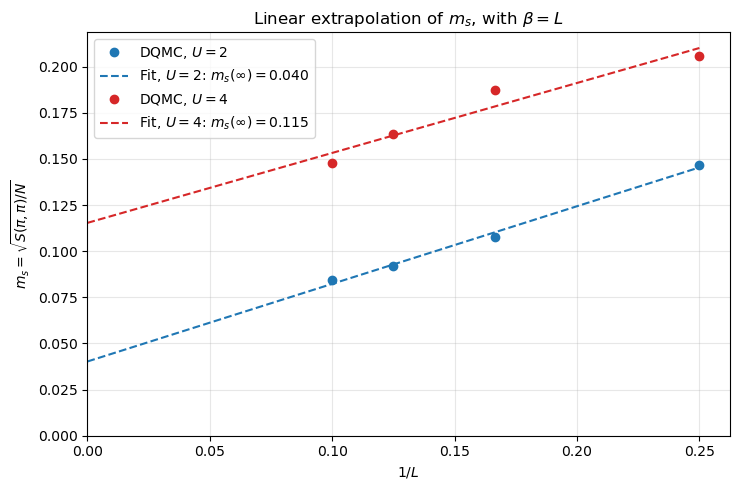

In [39]:
from scipy.stats import linregress


L_values = [4, 6, 8, 10]
U_values_to_plot = [2, 4]
colours = ["tab:blue", "tab:red"]

fig, ax = plt.subplots(figsize=(7.5, 5.0))

for U, colour in zip(U_values_to_plot, colours):
    inverse_L = []
    m_s_values = []

    for L in L_values:
        beta = float(L)
        saved_data = loaded_datasets[(L, beta)]

        parameters = saved_data["parameters"]
        results = saved_data["results"]
        safe_interval = max(parameters["safe_intervals"])

        S_pi_pi = results[safe_interval][U]["S_pi_pi"][0]

        inverse_L.append(1.0 / L)
        m_s_values.append(
            np.sqrt(S_pi_pi / (L * L))
        )

    inverse_L = np.array(inverse_L)
    m_s_values = np.array(m_s_values)

    # Direct linear fit: $m_s = slope/L + intercept$
    fit = linregress(inverse_L, m_s_values)

    fit_x = np.linspace(0.0, max(inverse_L), 100)
    fit_y = fit.slope * fit_x + fit.intercept

    ax.plot(
        inverse_L,
        m_s_values,
        "o",
        color=colour,
        label=rf"DQMC, $U={U}$",
    )

    ax.plot(
        fit_x,
        fit_y,
        "--",
        color=colour,
        label=(
            rf"Fit, $U={U}$: "
            rf"$m_s(\infty)={fit.intercept:.3f}$"
        ),
    )

    print(
        f"U={U}: extrapolated m_s = {fit.intercept:.6f}"
    )

ax.set_xlabel(r"$1/L$")
ax.set_ylabel(r"$m_s=\sqrt{S(\pi,\pi)/N}$")
ax.set_title(r"Linear extrapolation of $m_s$, with $\beta=L$")
ax.set_xlim(left=0.0)
ax.set_ylim(bottom=0.0)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()

plt.show()